In [10]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [4]:
class PCA:

    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, x):
        x_centered = x - np.mean(x, axis=0)

        covariance_matrix = np.cov(x_centered.T)
        eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
        sorted_indices = np.argsort(eigen_values)[::-1]

        eigen_values = eigen_values[sorted_indices]
        eigen_vectors = eigen_vectors[:, sorted_indices]

        self.components_ = eigen_vectors[:, :self.n_components]

        self.explained_variance_ = eigen_values[:self.n_components]

        self.explained_variance_ratio_ = self.explained_variance_ / np.sum(eigen_values)

    def transform(self, x):
        x_centered = x - np.mean(x, axis=0)
        return np.dot(x_centered, self.components_)

    def fit_transform(self, x):
        self.fit(x)
        return self.transform(x)


In [7]:
iris = load_iris()
x = iris.data

In [8]:
model = PCA(n_components=2)
x_reduced = model.fit_transform(x)

In [9]:
print("Original Shape:", x.shape)

print("Reduced Shape:", x_reduced.shape)

print("\nPrincipal Components:")
print(model.components_)

print("\nExplained Variance:")
print(model.explained_variance_)

print("\nExplained Variance Ratio:")
print(model.explained_variance_ratio_)

print("\nFirst 5 Transformed Samples:")
print(x_reduced[:5])

Original Shape: (150, 4)
Reduced Shape: (150, 2)

Principal Components:
[[ 0.36138659 -0.65658877]
 [-0.08452251 -0.73016143]
 [ 0.85667061  0.17337266]
 [ 0.3582892   0.07548102]]

Explained Variance:
[4.22824171 0.24267075]

Explained Variance Ratio:
[0.92461872 0.05306648]

First 5 Transformed Samples:
[[-2.68412563 -0.31939725]
 [-2.71414169  0.17700123]
 [-2.88899057  0.14494943]
 [-2.74534286  0.31829898]
 [-2.72871654 -0.32675451]]


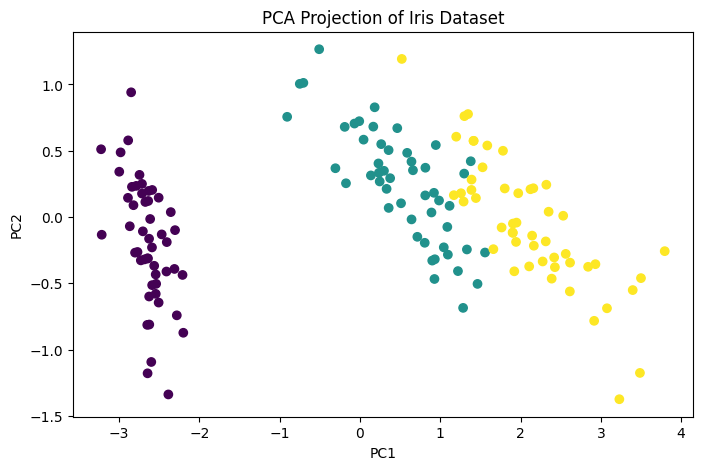

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    x_reduced[:,0],
    x_reduced[:,1],
    c=iris.target
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Iris Dataset")

plt.show()